# Modèles d'Ensemble sur la Production Minière

Ce notebook présente l'approche multivariée pour prédire la production minière à partir des variables climatiques et économiques. Après avoir testé des modèles linéaires et régularisés, nous explorons ici des modèles d'ensemble capables de capturer des relations non linéaires et des interactions complexes. Nous utilisons :

- **Random Forest** avec Grid Search pour optimiser les hyperparamètres et réduire la variance,
- **XGBoost** avec Randomized Search pour maximiser la performance via le boosting.

Les données sont séparées en ensembles d'entraînement (80%) et de test (20%). Pour les modèles d'arbres, nous utilisons les valeurs brutes sans standardisation.


## 1. Importation des Bibliothèques et Chargement des Données

Nous importons les librairies nécessaires et chargeons le jeu de données.


In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV, RandomizedSearchCV, train_test_split
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
import matplotlib.pyplot as plt

In [3]:
# Chargement et préparation des données
df = pd.read_csv(r"C:\Users\march\OneDrive\Bureau\Data_Science\Dossier\03.code\final_merged_data_normalized.csv", sep=",")  # Adapter le chemin si nécessaire

df['Date'] = pd.to_datetime(df['Date'])
df['Year'] = df['Date'].dt.year
# Vérifiez un aperçu du jeu de données
print(df.head())

        Date             Mine  Production   Latitude  Longitude  Cloud_Cover  \
0 2003-01-01           Andina   19.799999 -33.150873 -70.261021    24.800001   
1 2003-01-01         Salvador    5.700000 -26.282693 -69.597913    47.799999   
2 2003-01-01       Collahuasi   35.799999 -20.982384 -68.632167    74.599998   
3 2003-01-01  Quebrada Blanca    6.300000 -21.004622 -68.799554    74.599998   
4 2003-01-01          El Abra   17.500000 -21.925813 -68.829683    71.700005   

   Diurnal_Temp_Range    Frost_Days  Potential_Evapotranspiration  \
0           11.200000  6.177600e+14                           4.4   
1            8.200000  0.000000e+00                           4.4   
2           10.100000  8.873280e+14                           3.1   
3            9.800000  7.594560e+14                           3.1   
4            9.400001  4.345920e+14                           3.3   

   Cloud_Cover_historique  ...  Anomalie_Temperature_norm  Temp_Min_norm  \
0               31.300001  .

In [6]:
# Sélection des variables clés
key_vars = ['Production', 'Temperature', 'Precipitation', 'Cloud_Cover', 'Diurnal_Temp_Range', 
            'Frost_Days', 'Potential_Evapotranspiration', 'Anomalie_Cloud_Cover',
            'Anomalie_Diurnal_Temp_Range', 'Anomalie_Frost_Days', 
            'Anomalie_Potential_Evapotranspiration', 'Anomalie_Precipitation', 'Anomalie_Temperature',
            'Temp_Min', 'Temp_Max', 'Vapor_Pressure', 'Wet_Days', 'Anomalie_Vapor_Pressure',
            'Anomalie_Wet_Days', 'prix_lme', 'export_tot']

df = df[['Date', 'Mine', 'Year'] + key_vars]


In [7]:
# Définir la variable cible et la liste des features
target_column = "Production"
feature_cols = [col for col in key_vars if col != target_column]

In [8]:
# Pour les modèles d'arbres, on peut utiliser les valeurs brutes sans standardisation
X = df[feature_cols]
y = df[target_column]

In [9]:
# Split 80/20 en ensembles d'entraînement et de test (split aléatoire)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)


In [10]:
# Conversion en array (les modèles d'arbres acceptent les valeurs brutes sous forme d'array)
X_train_tree = X_train.values
X_test_tree  = X_test.values

# 2. Définition d'une validation croisée temporelle

Nous définissons une validation croisée temporelle avec 5 splits pour respecter l'ordre chronologique des données lors de l'optimisation des hyperparamètres.


In [11]:
# Définition d'une validation croisée temporelle
tscv = TimeSeriesSplit(n_splits=5)


# 3. Random Forest avec Grid Search CV

Nous créons un modèle Random Forest et utilisons `GridSearchCV` pour rechercher les meilleures combinaisons de `n_estimators` et `max_depth`. Le modèle optimisé est ensuite évalué sur l'ensemble de test.


In [12]:
# Création du modèle Random Forest et définition de la grille d'hyperparamètres
rf = RandomForestRegressor(random_state=0)
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 5, 10]
}
grid_search = GridSearchCV(rf, param_grid, cv=tscv, scoring='neg_mean_squared_error')
grid_search.fit(X_train_tree, y_train)
print("Meilleurs hyperparamètres RF:", grid_search.best_params_)
best_rf = grid_search.best_estimator_


Meilleurs hyperparamètres RF: {'max_depth': 5, 'n_estimators': 200}


In [23]:
# Évaluation sur l'ensemble d'entraînement
y_pred_rf_train = best_rf.predict(X_train_tree)
rmse_rf_train = np.sqrt(mean_squared_error(y_train, y_pred_rf_train))
r2_rf_train = r2_score(y_train, y_pred_rf_train)
print(f"Random Forest – Train : RMSE: {rmse_rf_train:.2f}, R²: {r2_rf_train:.2f}")

# Évaluation sur l'ensemble de test
y_pred_rf_test = best_rf.predict(X_test_tree)
rmse_rf_test = np.sqrt(mean_squared_error(y_test, y_pred_rf_test))
r2_rf_test = r2_score(y_test, y_pred_rf_test)
print(f"Random Forest – Test  : RMSE: {rmse_rf_test:.2f}, R²: {r2_rf_test:.2f}")


Random Forest – Train : RMSE: 21.98, R²: 0.19
Random Forest – Test  : RMSE: 24.44, R²: 0.10


# 4. XGBoost avec Randomized Search CV

Nous implémentons un modèle XGBoost et utilisons `RandomizedSearchCV` pour explorer un espace d'hyperparamètres (nombre d'arbres, profondeur et taux d'apprentissage). Le modèle optimisé est évalué sur l'ensemble de test.


In [15]:
# Création du modèle XGBoost et définition de l'espace d'hyperparamètres
xgb_model = XGBRegressor(objective='reg:squarederror', random_state=0)
param_dist = {
    'n_estimators': [50, 100, 200],
    'max_depth': [3, 6, 10],
    'learning_rate': [0.01, 0.1, 0.2]
}
random_search = RandomizedSearchCV(xgb_model, param_distributions=param_dist, n_iter=5, 
                                   cv=tscv, scoring='neg_mean_squared_error', random_state=0)
random_search.fit(X_train_tree, y_train)
print("Meilleurs hyperparamètres XGBoost:", random_search.best_params_)
best_xgb = random_search.best_estimator_

Meilleurs hyperparamètres XGBoost: {'n_estimators': 200, 'max_depth': 3, 'learning_rate': 0.01}


In [22]:
# Évaluation sur l'ensemble d'entraînement
y_pred_xgb_train = best_xgb.predict(X_train_tree)
mse_xgb_train = mean_squared_error(y_train, y_pred_xgb_train)
rmse_xgb_train = np.sqrt(mse_xgb_train)
r2_xgb_train = r2_score(y_train, y_pred_xgb_train)
print(f"XGBoost – Train : RMSE: {rmse_xgb_train:.2f}, R²: {r2_xgb_train:.2f}")

# Évaluation sur l'ensemble test
y_pred_xgb_test = best_xgb.predict(X_test_tree)
mse_xgb_test = mean_squared_error(y_test, y_pred_xgb_test)
rmse_xgb_test = np.sqrt(mse_xgb_test)
r2_xgb_test = r2_score(y_test, y_pred_xgb_test)
print(f"XGBoost – Test  : RMSE: {rmse_xgb_test:.2f}, R²: {r2_xgb_test:.2f}")


XGBoost – Train : RMSE: 22.98, R²: 0.11
XGBoost – Test  : RMSE: 24.55, R²: 0.09


# 5. Importance des variables (XGBoost)

Nous extrayons l'importance des variables selon le modèle XGBoost. Cela nous permet d'identifier rapidement les facteurs les plus influents dans la prédiction de la production.


In [18]:
# Extraction de l'importance des variables et affichage des 5 plus importantes
feature_importances = pd.Series(best_xgb.feature_importances_, index=feature_cols).sort_values(ascending=False)
print("Top 5 variables importantes (XGBoost):\n", feature_importances.head(5))


Top 5 variables importantes (XGBoost):
 Temp_Min                0.101592
Wet_Days                0.079768
Anomalie_Temperature    0.078879
Vapor_Pressure          0.077484
Frost_Days              0.068453
dtype: float32


# 6. Interprétation avancée avec SHAP pour XGBoost

Pour approfondir l'interprétation du modèle, nous utilisons SHAP pour calculer et visualiser l'influence de chaque variable sur les prédictions. La visualisation (par exemple avec `shap.summary_plot`) doit être réalisée dans un environnement interactif.


In [20]:
!pip install shap --quiet

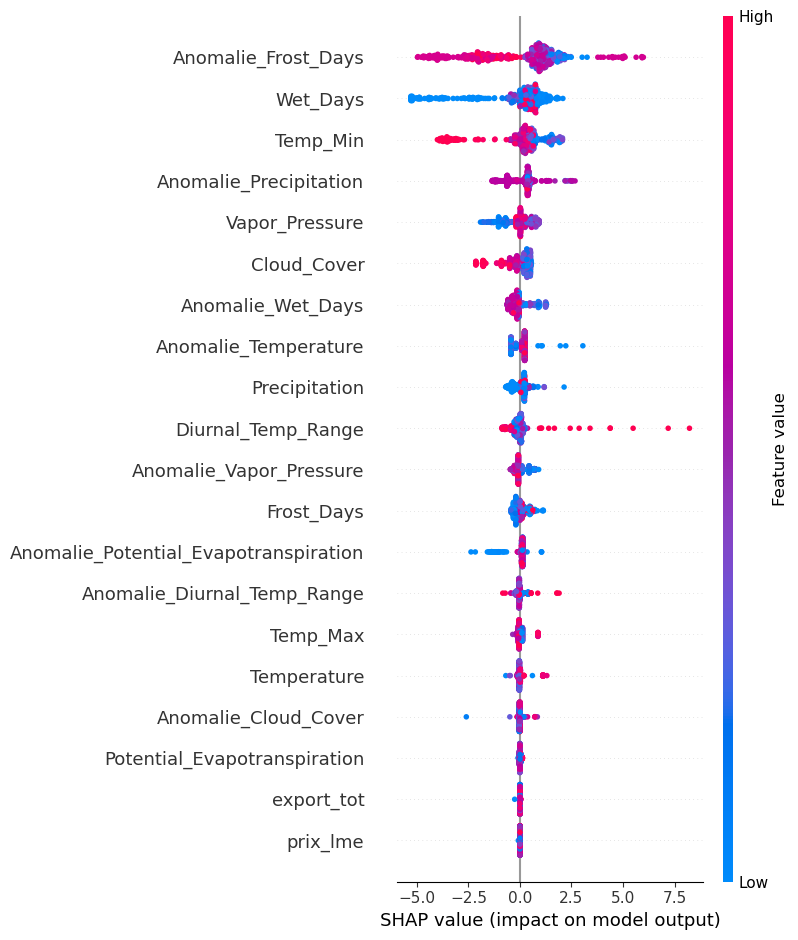

In [21]:
import shap
# Création de l'explainer basé sur le modèle XGBoost entraîné et les données d'entraînement
explainer = shap.Explainer(best_xgb, X_train)
shap_values = explainer(X_test)

# Pour visualiser l'importance globale des variables
shap.summary_plot(shap_values, X_test, feature_names=feature_cols)


Les deux modèles (Random Forest et XGBoost) expliquent une part limitée de la production, avec des R² autour de 0,10 sur l’ensemble de test. Random Forest affiche un léger avantage (R²=0,10 contre 0,09 pour XGBoost), mais présente davantage de sur-apprentissage (écart plus important entre train et test). Les variables les plus influentes selon XGBoost sont principalement climatiques : Temp_Min, Wet_Days, Anomalie_Temperature, Vapor_Pressure et Frost_Days. Les graphes SHAP montrent que l’effet de ces variables sur la production peut varier selon leur niveau (faible ou élevé), soulignant l’importance de la température et de l’humidité. Toutefois, le pouvoir prédictif global reste faible, suggérant la nécessité d’enrichir les variables explicatives (données économiques, retard temporel, etc.) pour mieux capturer la complexité du processus de production.